# FEATURE ENGINEERING — Dataset Klasifikasi Sampah

Notebook ini merupakan tahap lanjutan dari proses EDA pada dataset klasifikasi sampah. Tujuannya adalah melakukan **Feature Engineering** dengan menambahkan fitur-fitur baru yang relevan berdasarkan temuan EDA, meliputi:

1. **`aspect_ratio`** — rasio lebar terhadap tinggi gambar
2. **`resolution_category`** — kategorisasi resolusi gambar (Low / Medium / High)
3. **`file_size_category`** — kategorisasi ukuran file (Small / Normal / Large)
4. **`color_mode_label`** — label untuk mode warna gambar
5. **`waste_group`** — pengelompokan kelas sampah berdasarkan sifat pengelolaannya (Recyclable / Organic / Hazardous / Residu)
6. **`image_quality_flag`** — flag kualitas gambar berdasarkan kombinasi resolusi dan ukuran file
7. **`needs_augmentation`** — flag apakah kelas memerlukan augmentasi karena class imbalance

## IMPORT LIBRARY

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## LOAD DATA

In [2]:
df = pd.read_csv('eda_result.csv')
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 2003 entries, 0 to 2002
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   class         2003 non-null   str    
 1   filename      2003 non-null   str    
 2   extension     2003 non-null   str    
 3   width         2003 non-null   int64  
 4   height        2003 non-null   int64  
 5   mode          2003 non-null   str    
 6   file_size_kb  2003 non-null   float64
dtypes: float64(1), int64(2), str(4)
memory usage: 211.6 KB


,class,filename,extension,width,height,mode,file_size_kb
0,hazardous,hazardous_hazardous_hazardous_hazardous_batter...,.jpg,224,224,RGB,13.84
1,hazardous,hazardous_hazardous_hazardous_hazardous_batter...,.jpg,224,224,RGB,13.83
2,hazardous,hazardous_hazardous_hazardous_hazardous_batter...,.jpg,224,224,RGB,12.78
3,hazardous,hazardous_hazardous_hazardous_hazardous_batter...,.jpg,224,224,RGB,14.76
4,hazardous,hazardous_hazardous_hazardous_hazardous_batter...,.jpg,224,224,RGB,15.88


## ANALISIS OUTLIER UKURAN GAMBAR

Sebelum feature engineering, dilakukan deteksi outlier pada dimensi gambar (`width`, `height`) dan ukuran file (`file_size_kb`) menggunakan metode IQR.

In [3]:
for col in ['width', 'height', 'file_size_kb']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f'=== OUTLIER: {col} ===')
    print(f'  Q1            : {Q1:.2f}')
    print(f'  Q3            : {Q3:.2f}')
    print(f'  IQR           : {IQR:.2f}')
    print(f'  Lower Bound   : {lower_bound:.2f}')
    print(f'  Upper Bound   : {upper_bound:.2f}')
    print(f'  Jumlah Outlier: {len(outliers)} baris ({len(outliers)/len(df)*100:.2f}%)')
    print()

=== OUTLIER: width ===
  Q1            : 224.00
  Q3            : 224.00
  IQR           : 0.00
  Lower Bound   : 224.00
  Upper Bound   : 224.00
  Jumlah Outlier: 0 baris (0.00%)

=== OUTLIER: height ===
  Q1            : 224.00
  Q3            : 224.00
  IQR           : 0.00
  Lower Bound   : 224.00
  Upper Bound   : 224.00
  Jumlah Outlier: 0 baris (0.00%)

=== OUTLIER: file_size_kb ===
  Q1            : 11.66
  Q3            : 21.21
  IQR           : 9.56
  Lower Bound   : -2.68
  Upper Bound   : 35.55
  Jumlah Outlier: 45 baris (2.25%)



**Insight:** Outlier pada dimensi gambar dan ukuran file tidak dihapus karena gambar dengan resolusi ekstrem atau ukuran file yang besar/kecil tetap merupakan data valid. Informasi ini justru akan dimanfaatkan sebagai fitur (`resolution_category`, `file_size_category`, `image_quality_flag`) untuk menandai gambar yang berpotensi bermasalah selama proses pelatihan model.

## FEATURE ENGINEERING

### 1. Aspect Ratio

Rasio lebar terhadap tinggi gambar (`width / height`). Gambar dengan rasio jauh dari 1.0 menunjukkan gambar yang sangat landscape atau portrait, yang mungkin memerlukan crop sebelum di-resize ke ukuran standar.

In [4]:
df['aspect_ratio'] = (df['width'] / df['height']).round(4)

print('=== STATISTIK DESKRIPTIF aspect_ratio ===')
print(df['aspect_ratio'].describe().round(4))

=== STATISTIK DESKRIPTIF aspect_ratio ===
count    2003.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
Name: aspect_ratio, dtype: float64


### 2. Resolution Category

Kategorisasi resolusi gambar berdasarkan area piksel (`width × height`):
- **Low**: < 50.000 piksel (kemungkinan kualitas terlalu rendah untuk model)
- **Medium**: 50.000 – 500.000 piksel (resolusi umum yang cukup untuk pelatihan)
- **High**: > 500.000 piksel (resolusi tinggi, akan di-downscale saat preprocessing)

In [5]:
df['pixel_area'] = df['width'] * df['height']

def categorize_resolution(area):
    if area < 50_000:
        return 'Low'
    elif area <= 500_000:
        return 'Medium'
    else:
        return 'High'

df['resolution_category'] = df['pixel_area'].apply(categorize_resolution)

print('=== VALIDASI MAPPING resolution_category ===')
print(f'Missing/NaN setelah mapping: {df["resolution_category"].isnull().sum()}')
print()
print('=== DISTRIBUSI resolution_category ===')
print(df['resolution_category'].value_counts())

=== VALIDASI MAPPING resolution_category ===
Missing/NaN setelah mapping: 0

=== DISTRIBUSI resolution_category ===
resolution_category
Medium    2003
Name: count, dtype: int64


### 3. File Size Category

Kategorisasi ukuran file gambar berdasarkan nilai `file_size_kb`:
- **Small**: < 5 KB (kemungkinan gambar placeholder atau kualitas sangat rendah)
- **Normal**: 5 – 500 KB (rentang umum gambar yang sesuai untuk pelatihan)
- **Large**: > 500 KB (gambar besar, dapat memperlambat loading saat training)

In [6]:
def categorize_file_size(kb):
    if kb < 5:
        return 'Small'
    elif kb <= 500:
        return 'Normal'
    else:
        return 'Large'

df['file_size_category'] = df['file_size_kb'].apply(categorize_file_size)

print('=== VALIDASI MAPPING file_size_category ===')
print(f'Missing/NaN setelah mapping: {df["file_size_category"].isnull().sum()}')
print()
print('=== DISTRIBUSI file_size_category ===')
print(df['file_size_category'].value_counts())

=== VALIDASI MAPPING file_size_category ===
Missing/NaN setelah mapping: 0

=== DISTRIBUSI file_size_category ===
file_size_category
Normal    1980
Small       23
Name: count, dtype: int64


### 4. Color Mode Label

Standarisasi label mode warna gambar. Model klasifikasi umumnya mengharapkan input gambar dalam format RGB. Gambar dengan mode lain (RGBA, L, P, dll.) perlu dikonversi terlebih dahulu.

In [7]:
color_mode_mapping = {
    'RGB'  : 'RGB',
    'RGBA' : 'RGBA_needs_conversion',
    'L'    : 'Grayscale_needs_conversion',
    'P'    : 'Palette_needs_conversion',
    'CMYK' : 'CMYK_needs_conversion',
    '1'    : 'Binary_needs_conversion',
}

df['color_mode_label'] = df['mode'].map(color_mode_mapping).fillna('Unknown_needs_inspection')

print('=== VALIDASI MAPPING color_mode_label ===')
print(f'Missing/NaN setelah mapping: {df["color_mode_label"].isnull().sum()}')
print()
print('=== CROSS-CHECK: mode vs color_mode_label ===')
cross_check = df.groupby(['mode', 'color_mode_label']).size().reset_index(name='Jumlah Gambar')
print(cross_check.to_string(index=False))

=== VALIDASI MAPPING color_mode_label ===
Missing/NaN setelah mapping: 0

=== CROSS-CHECK: mode vs color_mode_label ===
mode color_mode_label  Jumlah Gambar
 RGB              RGB           2003


### 5. Waste Group

Pengelompokan kelas sampah ke dalam grup berdasarkan sifat pengelolaannya. Klasifikasi dilakukan berdasarkan referensi:
1. **SNI 3242:2008** (Pengelolaan Sampah Permukiman) — mendefinisikan kategori sampah organik, anorganik (recyclable), dan B3 (hazardous).
2. **Peraturan Menteri LHK No. 75 Tahun 2019** — mendefinisikan sampah spesifik dan residu sebagai golongan tersendiri.

In [8]:
# melihat kelas yang ada pada dataset
print('=== KELAS YANG ADA ===')
print(df['class'].value_counts())

=== KELAS YANG ADA ===
class
Kaca          452
Plastik       283
hazardous     255
organic       232
recyclable    211
Residu        205
Kardus        167
Kertas         99
Logam          99
Name: count, dtype: int64


In [9]:
waste_group_mapping = {
    'Kaca'       : 'Recyclable',
    'Kardus'     : 'Recyclable',
    'Kertas'     : 'Recyclable',
    'Logam'      : 'Recyclable',
    'Plastik'    : 'Recyclable',
    'recyclable' : 'Recyclable',
    'organic'    : 'Organic',
    'hazardous'  : 'Hazardous',
    'Residu'     : 'Residu',
}

df['waste_group'] = df['class'].map(waste_group_mapping)

print('=== VALIDASI MAPPING waste_group ===')
print(f'Missing/NaN setelah mapping: {df["waste_group"].isnull().sum()}')
print()
print('=== CROSS-CHECK: class vs waste_group ===')
cross_check = df.groupby(['class', 'waste_group']).size().reset_index(name='Jumlah Gambar')
print(cross_check.to_string(index=False))

=== VALIDASI MAPPING waste_group ===
Missing/NaN setelah mapping: 0

=== CROSS-CHECK: class vs waste_group ===
     class waste_group  Jumlah Gambar
      Kaca  Recyclable            452
    Kardus  Recyclable            167
    Kertas  Recyclable             99
     Logam  Recyclable             99
   Plastik  Recyclable            283
    Residu      Residu            205
 hazardous   Hazardous            255
   organic     Organic            232
recyclable  Recyclable            211


In [10]:
# Proporsi waste_group
proporsi_group = df['waste_group'].value_counts(normalize=True).mul(100).round(2)
print('=== PROPORSI waste_group (% jumlah gambar) ===')
print(proporsi_group)

=== PROPORSI waste_group (% jumlah gambar) ===
waste_group
Recyclable    65.45
Hazardous     12.73
Organic       11.58
Residu        10.23
Name: proportion, dtype: float64


**Insight:** 
- Pengelompokan `waste_group` memungkinkan analisis performa model tidak hanya pada level kelas individu, tetapi juga pada level kategori pengelolaan sampah.
- Kelompok **Recyclable** menjadi grup terbesar karena mencakup 5 kelas spesifik material (Kaca, Kardus, Kertas, Logam, Plastik) ditambah kelas `recyclable`.
- `waste_group` dapat digunakan sebagai fitur tambahan untuk model hierarkis (coarse-to-fine classification).

### 6. Image Quality Flag

Flag kualitas gambar berdasarkan kombinasi `resolution_category` dan `file_size_category`:
- **Good**: resolusi Medium/High dengan file size Normal/Large
- **Review**: kombinasi yang menunjukkan potensi masalah kualitas
- **Poor**: resolusi Low atau file size Small — berpotensi tidak layak untuk pelatihan model

In [11]:
def flag_image_quality(row):
    res  = row['resolution_category']
    size = row['file_size_category']

    if res == 'Low' or size == 'Small':
        return 'Poor'
    elif res == 'High' and size == 'Large':
        return 'Good'
    elif res == 'Medium' and size in ['Normal', 'Large']:
        return 'Good'
    elif res == 'High' and size == 'Normal':
        return 'Good'
    else:
        return 'Review'

df['image_quality_flag'] = df.apply(flag_image_quality, axis=1)

print('=== VALIDASI image_quality_flag ===')
print(f'Missing/NaN setelah mapping: {df["image_quality_flag"].isnull().sum()}')
print()
print('=== DISTRIBUSI image_quality_flag ===')
print(df['image_quality_flag'].value_counts())
print()

# Cross-check per kelas
print('=== CROSS-CHECK: class vs image_quality_flag ===')
cross_quality = df.groupby(['class', 'image_quality_flag']).size().unstack(fill_value=0)
print(cross_quality.to_string())

=== VALIDASI image_quality_flag ===
Missing/NaN setelah mapping: 0

=== DISTRIBUSI image_quality_flag ===
image_quality_flag
Good    1980
Poor      23
Name: count, dtype: int64

=== CROSS-CHECK: class vs image_quality_flag ===
image_quality_flag  Good  Poor
class                         
Kaca                 438    14
Kardus               166     1
Kertas                99     0
Logam                 97     2
Plastik              277     6
Residu               205     0
hazardous            255     0
organic              232     0
recyclable           211     0


### 7. Needs Augmentation Flag

Flag apakah suatu kelas memerlukan augmentasi data karena jumlah sampelnya di bawah threshold tertentu. Threshold ditetapkan pada **80% dari rata-rata jumlah gambar per kelas**, mengikuti praktik umum penanganan class imbalance pada dataset gambar.

In [12]:
class_counts = df['class'].value_counts()
mean_count   = class_counts.mean()
threshold    = mean_count * 0.8

print('=== STATISTIK JUMLAH GAMBAR PER KELAS ===')
print(class_counts)
print(f'\nRata-rata jumlah gambar per kelas : {mean_count:.0f}')
print(f'Threshold (80% dari rata-rata)    : {threshold:.0f}')

# Kelas yang membutuhkan augmentasi
classes_need_aug = class_counts[class_counts < threshold].index.tolist()
print(f'\nKelas yang memerlukan augmentasi  : {classes_need_aug}')

=== STATISTIK JUMLAH GAMBAR PER KELAS ===
class
Kaca          452
Plastik       283
hazardous     255
organic       232
recyclable    211
Residu        205
Kardus        167
Kertas         99
Logam          99
Name: count, dtype: int64

Rata-rata jumlah gambar per kelas : 223
Threshold (80% dari rata-rata)    : 178

Kelas yang memerlukan augmentasi  : ['Kardus', 'Kertas', 'Logam']


In [13]:
df['needs_augmentation'] = df['class'].apply(lambda c: 'Yes' if c in classes_need_aug else 'No')

print('=== VALIDASI needs_augmentation ===')
print(f'Missing/NaN setelah mapping: {df["needs_augmentation"].isnull().sum()}')
print()
print('=== PROPORSI BERDASARKAN JUMLAH GAMBAR ===')
proporsi_aug = df['needs_augmentation'].value_counts(normalize=True).mul(100).round(2)
print(proporsi_aug)
print()

# Cross-check: kelas yang butuh augmentasi
print('=== CROSS-CHECK: class vs needs_augmentation ===')
cross_aug = df.groupby(['class', 'needs_augmentation']).size().reset_index(name='Jumlah Gambar')
print(cross_aug.to_string(index=False))

=== VALIDASI needs_augmentation ===
Missing/NaN setelah mapping: 0

=== PROPORSI BERDASARKAN JUMLAH GAMBAR ===
needs_augmentation
No     81.78
Yes    18.22
Name: proportion, dtype: float64

=== CROSS-CHECK: class vs needs_augmentation ===
     class needs_augmentation  Jumlah Gambar
      Kaca                 No            452
    Kardus                Yes            167
    Kertas                Yes             99
     Logam                Yes             99
   Plastik                 No            283
    Residu                 No            205
 hazardous                 No            255
   organic                 No            232
recyclable                 No            211


**Insight:** 
- Kelas yang memiliki gambar di bawah threshold direkomendasikan untuk dilakukan augmentasi (flip horizontal, rotasi, brightness jitter, dll.) sebelum proses pelatihan model.
- Flag `needs_augmentation` dapat digunakan dalam pipeline preprocessing untuk secara otomatis menentukan kelas mana yang mendapat perlakuan augmentasi lebih agresif.

## VISUALISASI HASIL FEATURE ENGINEERING

C:\Users\ACER\AppData\Local\Temp\ipykernel_12088\4200975494.py:73: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1, 2].boxplot(data_to_plot, labels=groups, patch_artist=True)


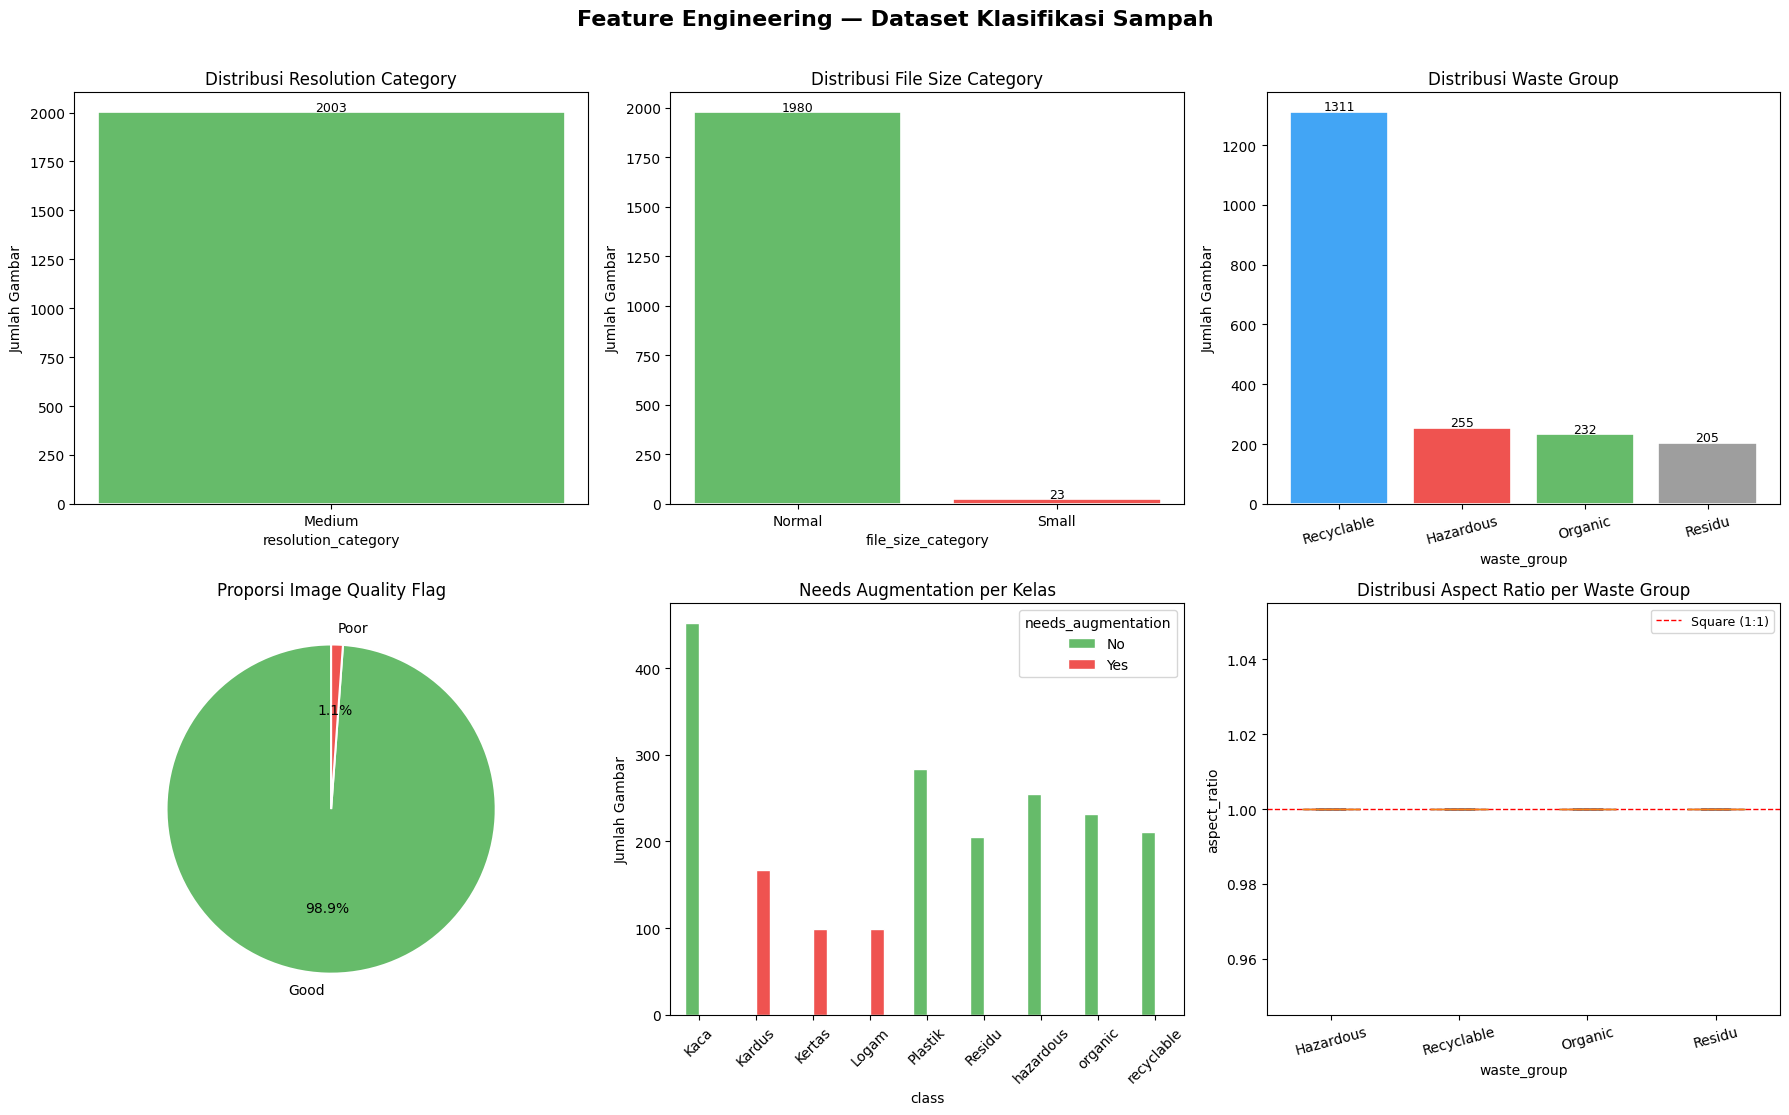

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Feature Engineering — Dataset Klasifikasi Sampah', fontsize=16, fontweight='bold', y=1.01)

palette_res  = {'Low': '#EF5350', 'Medium': '#66BB6A', 'High': '#42A5F5'}
palette_size = {'Small': '#EF5350', 'Normal': '#66BB6A', 'Large': '#FFA726'}
palette_qual = {'Good': '#66BB6A', 'Review': '#FFA726', 'Poor': '#EF5350'}
palette_aug  = {'Yes': '#EF5350', 'No': '#66BB6A'}
palette_grp  = {'Recyclable': '#42A5F5', 'Organic': '#66BB6A', 'Hazardous': '#EF5350', 'Residu': '#9E9E9E'}

# Plot 1: Distribusi resolution_category
res_data = df['resolution_category'].value_counts()
axes[0, 0].bar(res_data.index, res_data.values,
               color=[palette_res.get(l, '#9E9E9E') for l in res_data.index],
               edgecolor='white', linewidth=1.2)
axes[0, 0].set_title('Distribusi Resolution Category', fontsize=12)
axes[0, 0].set_xlabel('resolution_category')
axes[0, 0].set_ylabel('Jumlah Gambar')
for bar in axes[0, 0].patches:
    axes[0, 0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                    f'{int(bar.get_height())}', ha='center', fontsize=9)

# Plot 2: Distribusi file_size_category
size_data = df['file_size_category'].value_counts()
axes[0, 1].bar(size_data.index, size_data.values,
               color=[palette_size.get(l, '#9E9E9E') for l in size_data.index],
               edgecolor='white', linewidth=1.2)
axes[0, 1].set_title('Distribusi File Size Category', fontsize=12)
axes[0, 1].set_xlabel('file_size_category')
axes[0, 1].set_ylabel('Jumlah Gambar')
for bar in axes[0, 1].patches:
    axes[0, 1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                    f'{int(bar.get_height())}', ha='center', fontsize=9)

# Plot 3: Distribusi waste_group
grp_data = df['waste_group'].value_counts()
axes[0, 2].bar(grp_data.index, grp_data.values,
               color=[palette_grp.get(l, '#9E9E9E') for l in grp_data.index],
               edgecolor='white', linewidth=1.2)
axes[0, 2].set_title('Distribusi Waste Group', fontsize=12)
axes[0, 2].set_xlabel('waste_group')
axes[0, 2].set_ylabel('Jumlah Gambar')
axes[0, 2].tick_params(axis='x', rotation=15)
for bar in axes[0, 2].patches:
    axes[0, 2].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                    f'{int(bar.get_height())}', ha='center', fontsize=9)

# Plot 4: Distribusi image_quality_flag
qual_data = df['image_quality_flag'].value_counts()
axes[1, 0].pie(
    qual_data,
    labels=qual_data.index,
    autopct='%1.1f%%',
    colors=[palette_qual.get(l, '#9E9E9E') for l in qual_data.index],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[1, 0].set_title('Proporsi Image Quality Flag', fontsize=12)

# Plot 5: needs_augmentation per kelas
aug_class = df.groupby(['class', 'needs_augmentation']).size().unstack(fill_value=0)
aug_class.plot(kind='bar', ax=axes[1, 1],
               color=[palette_aug.get(l, '#9E9E9E') for l in aug_class.columns],
               edgecolor='white', linewidth=1.0)
axes[1, 1].set_title('Needs Augmentation per Kelas', fontsize=12)
axes[1, 1].set_xlabel('class')
axes[1, 1].set_ylabel('Jumlah Gambar')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].legend(title='needs_augmentation')

# Plot 6: Distribusi aspect_ratio per waste_group
groups = df['waste_group'].dropna().unique()
data_to_plot = [df[df['waste_group'] == g]['aspect_ratio'].dropna().values for g in groups]
bp = axes[1, 2].boxplot(data_to_plot, labels=groups, patch_artist=True)
for patch, grp in zip(bp['boxes'], groups):
    patch.set_facecolor(palette_grp.get(grp, '#9E9E9E'))
axes[1, 2].set_title('Distribusi Aspect Ratio per Waste Group', fontsize=12)
axes[1, 2].set_xlabel('waste_group')
axes[1, 2].set_ylabel('aspect_ratio')
axes[1, 2].axhline(y=1.0, color='red', linestyle='--', linewidth=1, label='Square (1:1)')
axes[1, 2].legend(fontsize=9)
axes[1, 2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('feature_engineering_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

## RINGKASAN FITUR BARU

In [15]:
new_features = [
    'aspect_ratio', 'pixel_area', 'resolution_category',
    'file_size_category', 'color_mode_label',
    'waste_group', 'image_quality_flag', 'needs_augmentation'
]

print('=== RINGKASAN FITUR BARU ===')
for feat in new_features:
    null_count = df[feat].isnull().sum()
    dtype      = df[feat].dtype
    if df[feat].dtype == object:
        unique_vals = df[feat].unique().tolist()
        print(f'{feat:<25} | dtype: {str(dtype):<10} | missing: {null_count} | unique: {unique_vals}')
    else:
        print(f'{feat:<25} | dtype: {str(dtype):<10} | missing: {null_count} | min: {df[feat].min():.4f}, max: {df[feat].max():.4f}')

print(f'\nTotal kolom sebelum FE : {len(df.columns) - len(new_features)}')
print(f'Total kolom setelah FE : {len(df.columns)}')
print(f'Fitur baru yang ditambahkan: {len(new_features)}')

=== RINGKASAN FITUR BARU ===
aspect_ratio              | dtype: float64    | missing: 0 | min: 1.0000, max: 1.0000
pixel_area                | dtype: int64      | missing: 0 | min: 50176.0000, max: 50176.0000


ValueError: Unknown format code 'f' for object of type 'str'

## INTERPRETASI HASIL

- **`aspect_ratio`** dan **`pixel_area`** memberikan informasi kuantitatif tentang karakteristik geometri gambar yang relevan untuk menentukan strategi resize/crop.
- **`resolution_category`** dan **`file_size_category`** membantu mengidentifikasi gambar yang berpotensi bermasalah sebelum dimasukkan ke pipeline pelatihan.
- **`color_mode_label`** memastikan seluruh gambar non-RGB teridentifikasi untuk dikonversi ke RGB sebelum pelatihan.
- **`waste_group`** menyediakan label hierarkis untuk eksperimen model coarse-to-fine atau sebagai fitur tambahan untuk model ensemble.
- **`image_quality_flag`** memungkinkan filtering otomatis gambar berkualitas Poor sebelum pelatihan, sehingga meningkatkan kualitas data keseluruhan.
- **`needs_augmentation`** menyediakan panduan berbasis data untuk strategi augmentasi yang lebih terarah, mengatasi class imbalance secara spesifik per kelas.

## MENYIMPAN DATASET FINAL

In [ ]:
df.to_csv('data_final.csv', index=False)

print('=== DATASET FINAL TERSIMPAN ===')
print('File : data_final.csv')
print(f'Shape: {df.shape[0]} baris × {df.shape[1]} kolom')
print()
print('=== PREVIEW DATASET FINAL ===')
df.head()